# Session 6 — Demo 1 — The threshold is a money dial

**What this demo covers.** Session 5 ended with a question it could not answer. One model caught 12 of 66 bankrupt firms; another caught 57 but raised 272 false alarms. Which is better? Tonight we answer with money. A model gives every firm a **score**; we check whether that score is an honest probability, and turn it into a yes/no call with a **threshold**. We read the four cells of the **confusion matrix**, price each kind of mistake, slide the threshold and watch the cells move, draw the **ROC curve** and its area, **AUC**, as one grade for the whole menu of thresholds, and finally the **expected-cost curve** that picks a threshold for a given cost ratio. This is HW2 Part 5, as working code.

**Data.** `data/bankruptcy/taiwan_bankruptcy.csv`, with the same split as session 5.

**How to run.** Locally: top to bottom. Colab: uncomment the two `git clone` lines **and** the `%pip install catboost` line in the setup cell: `catboost` is not preinstalled in Colab.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# the Taiwan bankruptcy dataset (sessions 5 to 7)
BANKRUPTCY = Path("../../data/bankruptcy")

# --- Google Colab? Uncomment these lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# BANKRUPTCY = Path("course/data/bankruptcy")
# %pip install catboost

RECALL_COLOR = "#c0392b"
PRECISION_COLOR = "#4a7ebb"
FLAGGED_COLOR = "#7f8c8d"
COST_COLOR = "#4a7ebb"
BEST_COLOR = "#c0392b"
ROC_COLOR = "#4a7ebb"

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

## 1. Session 5's boosting, without class weights

The same firms, the same split and the same 300 trees as in session 5, Demo 3. One thing differs: **the class weights are off.** We switch them off on purpose. Weights push every score up, which works like moving the threshold for you. Tonight we move the threshold by hand, and section 11 shows what the weights do to it.

`bankrupt_proba` holds the model's score for every test firm (`.predict_proba(...)[:, 1]`, as in session 5). `y_true` holds the truth for the same firms as a plain array of 1 and 0.

In [3]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

firms = pd.read_csv(BANKRUPTCY / "taiwan_bankruptcy.csv")
firms.columns = firms.columns.str.strip()
firms = firms.drop(columns=["Net Income Flag"])

y = firms["Bankrupt?"]
X = firms.drop(columns=["Bankrupt?"])

# the session 5 split, so every model faces the same exam
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

boosting_model = CatBoostClassifier(
    iterations=300,
    random_seed=42,
    verbose=0,
)
boosting_model.fit(X_train, y_train)

bankrupt_proba = boosting_model.predict_proba(X_test)[:, 1]
y_true = y_test.to_numpy()
print(f"test firms: {len(y_true):,}, of them bankrupt: {y_true.sum()}")

test firms: 2,046, of them bankrupt: 66


## 2. A score, a probability and a threshold

The model gives every firm a number between 0 and 1, its **score**. Here are the three firms it worries about most and the three it worries about least, next to the truth:

In [4]:
firm_scores = pd.DataFrame({
    "bankrupt_proba": bankrupt_proba,
    "actually_bankrupt": y_true,
})
scores_high_to_low = firm_scores.sort_values("bankrupt_proba", ascending=False)

pd.concat([scores_high_to_low.head(3), scores_high_to_low.tail(3)]).round(3)

,bankrupt_proba,actually_bankrupt
193,0.972,1
61,0.954,1
248,0.954,1
382,0.000,0
1642,0.000,0
1062,0.000,0


(A score printed as 0.0 is rounded: it is tiny, not exactly zero, the same trap as `p_value 0.0` in session 4.)

We would like to read the score as a **probability**: 0.2 would mean "among firms like this one, about 2 in 10 go bankrupt". But a bank does not act on a probability. It makes a yes/no decision: send the firm to a credit review, or not. A **threshold** turns the score into that decision:

$$\text{flag the firm} \iff \text{score} \geq \text{threshold}$$

scikit-learn's `.predict()` uses 0.5, as you saw in session 5: "bankrupt" when it is more likely than not. Nothing forces a bank to use 0.5. Tonight is about choosing the threshold on purpose.

**Is the score really a probability?** A score is an honest probability if it keeps its promise: among the firms scored about 0.2, about 20% really go bankrupt. This property is called **calibration**. We can check it. Cut the test firms into score bands with `pd.cut` (session 3), then compare in each band the average score with the share that really went bankrupt (`groupby` with named `.agg`, session 2; `observed=True` as in session 3). We will need this check again in section 11, so it lives in a small function.

In [5]:
def summarize_score_bands(y_true, scores):
    """Firms, average score and real bankrupt share in each score band."""
    firms_by_score = pd.DataFrame({
        "score": scores,
        "actually_bankrupt": y_true,
    })
    firms_by_score["score_band"] = pd.cut(
        firms_by_score["score"],
        bins=[0, 0.02, 0.1, 0.3, 1],
    )
    return (
        firms_by_score
        .groupby("score_band", observed=True)
        .agg(
            firms=("actually_bankrupt", "size"),
            average_score=("score", "mean"),
            bankrupt_share=("actually_bankrupt", "mean"),
        )
        .round(3)
    )


summarize_score_bands(y_true, bankrupt_proba)

,firms,average_score,bankrupt_share
score_band,,,
"(0.0, 0.02]",1789,0.002,0.007
"(0.02, 0.1]",153,0.045,0.085
"(0.1, 0.3]",57,0.178,0.211
"(0.3, 1.0]",47,0.553,0.596


Read it row by row. The firms scored about 0.18 on average went bankrupt 21% of the time; the firms scored about 0.55, 60% of the time. Close enough: this model's scores are roughly honest. The top band holds only 47 firms, so its share is noisy.

That is not guaranteed. Many models give scores that only keep the *order* right: a higher score means more risk, but 0.2 does not mean 20%. Section 11 shows one way to break the promise: class weights.

When does it matter?

- **To choose a threshold by cost, the order is enough.** The cost curve in section 8 tries every threshold, so it works either way.
- **When the number itself goes into a formula, it must be honest:** expected loss = probability of default × exposure, a loan price, a reserve.

Repairing the scores is also called **calibration**, with methods such as Platt scaling and isotonic regression. That is beyond this course; a clear explanation, in Russian: [Yandex ML handbook, "How to evaluate probabilities"](https://contest.yandex.ru/tracks/ml/probabilistic-models/probability-estimation).

## 3. Four cells: the confusion matrix

At a threshold of 0.5 every test firm gets one of two calls, flagged or cleared, and every call lands in one of four cells. Session 5 counted them as caught, missed and false alarms. The table of the four cells has a name: the **confusion matrix**. It is session 5's `pd.crosstab(truth, call)`; scikit-learn makes it with `confusion_matrix(truth, call)`.

Its labels come from medicine, so read them once. **"Positive" is the class we hunt for**, here bankrupt. It does not mean good news. This is how textbooks usually draw the table, with the positive class first:

|  | called bankrupt (positive) | called healthy (negative) |
|---|---|---|
| **truly bankrupt** | **TP**, true positive: caught | **FN**, false negative: missed |
| **truly healthy** | **FP**, false positive: a false alarm | **TN**, true negative: correctly cleared |

The two rates from session 5 live in this table:

- **recall** = TP / (TP + FN), the top row: of all bankrupt firms, the share we caught;
- **precision** = TP / (TP + FP), the left column: of all our flags, the share that were real.

A longer walk through this table and every metric built on it, in Russian: [Yandex ML handbook, "Classification and regression metrics"](https://contest.yandex.ru/tracks/ml/model-evaluation/classification-and-regression-metrics).

**One trap: scikit-learn puts the classes in the other order.** It sorts them, 0 before 1, so healthy comes first and its top-left cell is TN. Read the labels before you read a cell.

🧪 **Toy example first:** session 5's six made-up firms, two of them bankrupt, three of them flagged. By eye: caught 1, missed 1, false alarms 2, correctly cleared 2.

In [6]:
from sklearn.metrics import confusion_matrix

toy_flags = pd.DataFrame({
    "actually_bankrupt": [1, 1, 0, 0, 0, 0],
    "called_bankrupt": [1, 0, 1, 1, 0, 0],
})
confusion_matrix(toy_flags["actually_bankrupt"], toy_flags["called_bankrupt"])

array([[2, 2],
       [1, 1]])

Rows are the truth (healthy, then bankrupt); columns are our call (cleared, then flagged). That is the textbook table with both rows and columns swapped, and the same layout as session 5's `crosstab`. The top row: of the four healthy firms, 2 cleared and 2 flagged by mistake. The bottom row: of the two bankrupt firms, 1 missed and 1 caught. Same as by eye.

`.ravel()` flattens the table row by row: top-left, top-right, bottom-left, bottom-right. That gives a fixed order, **tn, fp, fn, tp**, and four names on the left take the four numbers, as with `train_test_split` in session 5. Get the order wrong and recall and precision swap places, with no error.

In [7]:
toy_tn, toy_fp, toy_fn, toy_tp = confusion_matrix(
    toy_flags["actually_bankrupt"],
    toy_flags["called_bankrupt"],
).ravel()
print(
    f"caught (tp) {toy_tp}, missed (fn) {toy_fn}, "
    f"false alarms (fp) {toy_fp}, cleared (tn) {toy_tn}"
)

caught (tp) 1, missed (fn) 1, false alarms (fp) 2, cleared (tn) 2


**Back to the real test firms.** `bankrupt_proba >= 0.5` compares every score with 0.5 and gives True (flag) or False (clear), one per firm: a mask, as in session 2. Wrapping the matrix in a DataFrame puts words on its rows and columns. This labelled table is what HW2 Part 5 asks you to show.

In [8]:
called_bankrupt = bankrupt_proba >= 0.5

matrix_at_half = pd.DataFrame(
    confusion_matrix(y_true, called_bankrupt),
    index=["truly healthy", "truly bankrupt"],
    columns=["cleared", "flagged"],
)
matrix_at_half

,cleared,flagged
truly healthy,1972,8
truly bankrupt,52,14


The bottom-left cell is the expensive one: bankrupt firms we cleared. We are about to count the cells at many thresholds, so a small function does it: give it the truth, the scores and a threshold, get the four counts back. Then the three rates.

In [9]:
def count_cells(y_true, bankrupt_proba, threshold):
    """Confusion-matrix counts tn, fp, fn, tp at one threshold."""
    called_bankrupt = bankrupt_proba >= threshold
    return confusion_matrix(y_true, called_bankrupt).ravel()


tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, 0.5)
print(
    f"accuracy:  {(tp + tn) / len(y_true):.1%}\n"
    f"recall:    {tp / (tp + fn):.0%}  (share of bankrupt firms we caught)\n"
    f"precision: {tp / (tp + fp):.0%}  (share of our flags that were real)"
)

accuracy:  97.1%
recall:    21%  (share of bankrupt firms we caught)
precision: 64%  (share of our flags that were real)


Accuracy blends the four cells into one comfortable number. At 0.5 the model is *cautious*: it flags only the firms it is sure about. Precision is decent, recall is poor: four bankrupt firms out of five walk through.

## 4. Which mistake hurts more?

The two right calls, TP and TN, cost nothing extra. The two mistakes cost money, and rarely the same money. Which one hurts more depends on the business, not on the model:

| task | the positive class | the dearer mistake | the rate to watch |
|---|---|---|---|
| cancer screening | sick | FN: a sick patient sent home | recall |
| spam filter | spam | FP: an important email lost in the spam folder | precision |
| credit default (this data, HW2 loans) | defaults | usually FN: the lent money is lost | recall, with a price on false alarms |
| hotel cancellations (HW2) | cancels | FP: the room is resold and the guest arrives | precision, a ratio below 1 |

Why not just push up the rate you care about? Because each rate alone is easy to game. Flag every firm, and recall is 100%. Flag only the one firm the model is surest about, and precision is 100%. The loop below takes each (label, threshold) pair in turn. In the printout, `:<23` and `:>4` inside the f-string only pad a value to 23 or 4 characters, so the columns line up.

In [10]:
gaming_rules = [
    ("flag everyone", 0.0),
    ("flag only the top firm", bankrupt_proba.max()),
]
for label, threshold in gaming_rules:
    tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, threshold)
    print(
        f"{label:<23} caught {tp:>2} of {tp + fn}, false alarms {fp:>4}, "
        f"recall {tp / (tp + fn):>4.0%}, precision {tp / (tp + fp):>4.0%}"
    )

flag everyone           caught 66 of 66, false alarms 1980, recall 100%, precision   3%
flag only the top firm  caught  1 of 66, false alarms    0, recall   2%, precision 100%


Both rules score a "perfect" 100% on one rate, and both are useless. A real decision needs both mistakes in one number, and that number is money. Write a price into each cell. With a missed bankruptcy costing as much as 10 false alarms:

|  | called bankrupt | called healthy |
|---|---|---|
| **truly bankrupt** | 0 | 10 for each missed firm |
| **truly healthy** | 1 for each false alarm | 0 |

The cost of a threshold is each count times its price, added up: missed × 10 + false alarms × 1. Section 8 does exactly that, after we have seen all the thresholds the model offers.

## 5. Slide the dial

Nothing about the model changes below, only the **decision rule**: the threshold.

In [11]:
for threshold in [0.5, 0.3, 0.1, 0.04]:
    tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, threshold)
    print(
        f"threshold {threshold:<5} caught {tp:>2} of {tp + fn}, "
        f"false alarms {fp:>3}, "
        f"recall {tp / (tp + fn):>4.0%}, precision {tp / (tp + fp):>4.0%}"
    )

threshold 0.5   caught 14 of 66, false alarms   8, recall  21%, precision  64%
threshold 0.3   caught 28 of 66, false alarms  19, recall  42%, precision  60%
threshold 0.1   caught 40 of 66, false alarms  64, recall  61%, precision  38%
threshold 0.04  caught 49 of 66, false alarms 125, recall  74%, precision  28%


As the threshold falls, firms move from the "cleared" column to "flagged". Recall climbs, precision falls, and false alarms multiply.

## 6. The whole menu at once

Now every threshold from 0.01 to 0.99. Three small tools:

- `np.arange(0.01, 1.0, 0.01)` makes the numbers 0.01, 0.02, …, 0.99: start, stop before 1.0, step;
- `a if condition else b` is an if/else in one line;
- `np.nan` means "no number". At high thresholds the model flags nobody, so precision has nothing to divide by: the same `NaN` as the "everyone healthy" row in session 5.

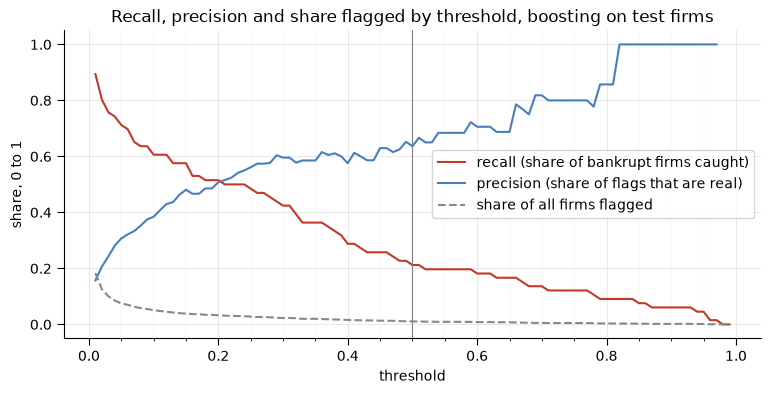

In [12]:
thresholds = np.arange(0.01, 1.0, 0.01)

recall_by_threshold = []
precision_by_threshold = []
flagged_share_by_threshold = []
for threshold in thresholds:
    tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, threshold)
    recall_by_threshold.append(tp / (tp + fn))
    precision_by_threshold.append(tp / (tp + fp) if tp + fp > 0 else np.nan)
    flagged_share_by_threshold.append((tp + fp) / len(y_true))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    thresholds,
    recall_by_threshold,
    color=RECALL_COLOR,
    label="recall (share of bankrupt firms caught)",
)
ax.plot(
    thresholds,
    precision_by_threshold,
    color=PRECISION_COLOR,
    label="precision (share of flags that are real)",
)
ax.plot(
    thresholds,
    flagged_share_by_threshold,
    color=FLAGGED_COLOR,
    linestyle="--",
    label="share of all firms flagged",
)
ax.axvline(0.5, color="gray", linewidth=0.8)
ax.set_title("Recall, precision and share flagged by threshold, boosting on test firms")
ax.set_xlabel("threshold")
ax.set_ylabel("share, 0 to 1")
ax.legend()
make_ax_better(ax, minor="x")
plt.show()

Two notes on reading the chart. The blue precision line stops just before the right edge: above that point the model flags nobody, and `np.nan` leaves a gap. The thin grey vertical line marks the default 0.5.

The curves fight: catching more bankrupt firms means flagging more healthy ones. The model offers a *menu* of operating points. Picking one is not a statistical question but a business one, and business speaks money. First, though, one grade for the model that holds for the whole menu.

## 7. ROC curve and AUC: one grade for the whole menu

Recall and precision change with every threshold. Before we pick a threshold, it helps to grade the model itself. The standard picture for that is the **ROC curve**. It uses two shares, one from each row of the confusion matrix:

- **y-axis, true positive rate** = TP / (TP + FN): the share of bankrupt firms we flag. It is recall under another name.
- **x-axis, false positive rate** = FP / (FP + TN): the share of healthy firms we flag by mistake.

Each threshold gives one point. A threshold above every score flags nobody: the point (0, 0). A threshold of 0 flags everyone: the point (1, 1). Lowering the threshold step by step walks from one corner to the other, and that path is the ROC curve. In plain words: **how many bankrupt firms do we catch for each share of healthy firms we bother?**

🧪 **Toy example:** two bankrupt firms (scores 0.8 and 0.3) and three healthy ones (0.6, 0.2 and 0.1). Lower the threshold through each score:

| threshold | flagged | caught, of 2 | false alarms, of 3 | true positive rate | false positive rate |
|---|---|---|---|---|---|
| above 0.8 | nobody | 0 | 0 | 0 | 0 |
| 0.8 | 0.8 | 1 | 0 | 0.5 | 0 |
| 0.6 | 0.8, 0.6 | 1 | 1 | 0.5 | 0.33 |
| 0.3 | 0.8, 0.6, 0.3 | 2 | 1 | 1 | 0.33 |
| 0.2 | four firms | 2 | 2 | 1 | 0.67 |
| 0.1 | everyone | 2 | 3 | 1 | 1 |

**AUC is the area under this curve.** The first stretch, up to a false positive rate of 0.33, sits at height 0.5: area 0.33 × 0.5 = 0.17. The rest, from 0.33 to 1, sits at height 1: area 0.67. Total: 0.83.

The same 0.83 has a second meaning, easier to say aloud. Take one random bankrupt firm and one random healthy firm. **AUC is the share of such pairs where the model gives the bankrupt firm the higher score.** Here there are 2 × 3 = 6 pairs. The 0.8 beats all three healthy firms; the 0.3 beats 0.2 and 0.1 but loses to 0.6. That makes 5 pairs won of 6, or 0.83. Area and pairs always agree.

`roc_curve` from scikit-learn returns the points: false positive rates, true positive rates and the thresholds behind them. It keeps only the corners of the path, so it skips the 0.2 row, which lies on the same flat stretch. The first threshold prints as `inf`, infinity: scikit-learn's way of saying "above every score". `roc_auc_score` returns the area. `fill_between` (session 5) shades it.

false positive rates: [0.   0.   0.33 0.33 1.  ]
true positive rates:  [0.  0.5 0.5 1.  1. ]
thresholds:           [inf 0.8 0.6 0.3 0.1]
AUC: 0.83


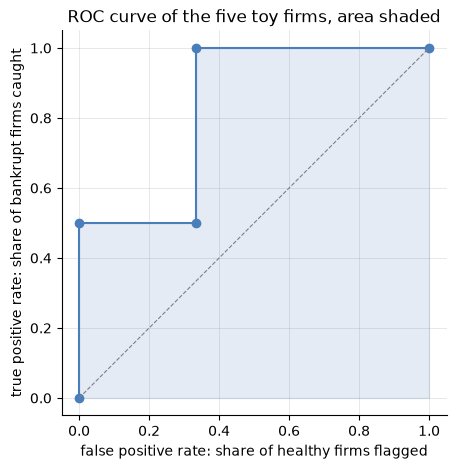

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

toy_scores = pd.DataFrame({
    "actually_bankrupt": [1, 1, 0, 0, 0],
    "bankrupt_proba": [0.8, 0.3, 0.6, 0.2, 0.1],
})
toy_false_positive_rate, toy_true_positive_rate, toy_thresholds = roc_curve(
    toy_scores["actually_bankrupt"],
    toy_scores["bankrupt_proba"],
)
toy_auc = roc_auc_score(toy_scores["actually_bankrupt"], toy_scores["bankrupt_proba"])
print(
    f"false positive rates: {toy_false_positive_rate.round(2)}\n"
    f"true positive rates:  {toy_true_positive_rate.round(2)}\n"
    f"thresholds:           {toy_thresholds}\n"
    f"AUC: {toy_auc:.2f}"
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(
    toy_false_positive_rate,
    toy_true_positive_rate,
    marker="o",
    color=ROC_COLOR,
)
ax.fill_between(
    toy_false_positive_rate,
    toy_true_positive_rate,
    color=ROC_COLOR,
    alpha=0.15,
)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=0.8,
)
ax.set_aspect("equal")
ax.set_title("ROC curve of the five toy firms, area shaded")
ax.set_xlabel("false positive rate: share of healthy firms flagged")
ax.set_ylabel("true positive rate: share of bankrupt firms caught")
make_ax_better(ax)
plt.show()

**Back to the real test firms.** Two models on one chart: our boosting, and a "model" that gives every firm a random score (`rng.uniform`, session 5), which knows nothing about bankruptcy. The dashed diagonal is where pure chance lands on average; the dotted corner is a perfect order. `roc_curve` returns three arrays, and here we don't need the thresholds: `_` is a name for a value we don't need.

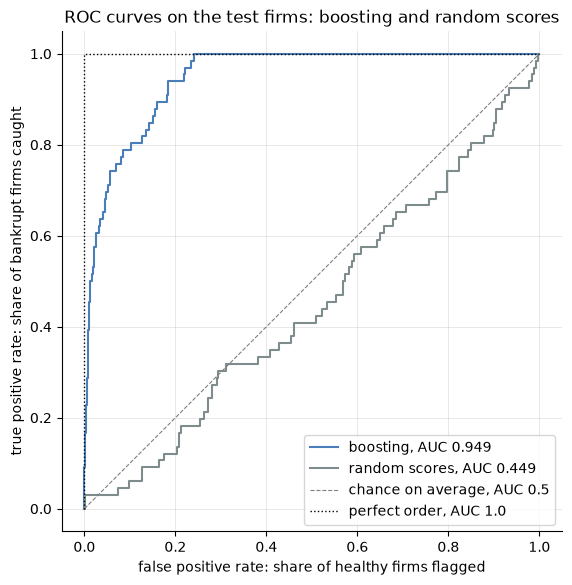

In [14]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_true,
    bankrupt_proba,
)
boosting_auc = roc_auc_score(y_true, bankrupt_proba)

rng = np.random.default_rng(0)
random_scores = rng.uniform(size=len(y_true))
random_false_positive_rate, random_true_positive_rate, _ = roc_curve(
    y_true,
    random_scores,
)
random_auc = roc_auc_score(y_true, random_scores)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(
    false_positive_rate,
    true_positive_rate,
    color=ROC_COLOR,
    label=f"boosting, AUC {boosting_auc:.3f}",
)
ax.plot(
    random_false_positive_rate,
    random_true_positive_rate,
    color=FLAGGED_COLOR,
    label=f"random scores, AUC {random_auc:.3f}",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=0.8,
    label="chance on average, AUC 0.5",
)
ax.plot(
    [0, 0, 1],
    [0, 1, 1],
    color="black",
    linestyle=":",
    linewidth=1,
    label="perfect order, AUC 1.0",
)
ax.set_aspect("equal")
ax.set_title("ROC curves on the test firms: boosting and random scores")
ax.set_xlabel("false positive rate: share of healthy firms flagged")
ax.set_ylabel("true positive rate: share of bankrupt firms caught")
ax.legend(loc="lower right")
make_ax_better(ax)
plt.show()

Read the chart:

- The **random scores** wander along the diagonal: whatever share of healthy firms they flag, they catch about the same share of bankrupt ones. Their AUC is 0.45, not exactly 0.5: with only 66 bankrupt firms, even a coin wobbles.
- The **boosting** curve shoots up near the left edge: it catches most bankrupt firms while bothering few healthy ones. Its AUC is 0.949: in 95% of pairs, the bankrupt firm gets the higher score.
- A **perfect** model would go straight up to the top-left corner: every bankrupt firm scored above every healthy one.

With rare positives, look at the left edge. A false positive rate of 0.05 sounds small, but here it means about 99 false alarms among 1,980 healthy firms; at that point the model catches about 70% of the bankrupt firms. Demo 3 names a curve made for rare positives, the precision–recall curve.

AUC grades the *order* of the firms, for all thresholds at once. It doesn't say where to cut. This model has an AUC of 0.949 and still caught only 21% of the bankrupt firms at 0.5: the order is good, and the cut at 0.5 sits in the wrong place. The threshold is a separate decision, and money makes it.

## 8. Money enters: the expected cost

Back to the price table from section 4: a missed bankruptcy costs as much as 10 false alarms. Your HW2 dataset has its own ratio, in the README table. Count everything in false alarms, and every threshold gets a price:

$$\text{expected cost} = \text{missed} \times 10 + \text{false alarms} \times 1$$

"Expected" means what this rule would cost on firms like these.

🧪 **Toy example first:** five made-up firms, two of them bankrupt (at 0.9 and 0.3), and three thresholds. By eye:

- at **0.5** we flag 0.9 and 0.6: one caught, one missed (the 0.3), one false alarm. Cost 10 + 1 = **11**;
- at **0.25** we also flag the 0.3: both caught, one false alarm. Cost **1**;
- at **0.1** we also flag the 0.2: both caught, two false alarms. Cost **2**.

The best of the three is 0.25. `count_cells` should agree.

In [15]:
COST_RATIO = 10

toy_firms = pd.DataFrame({
    "actually_bankrupt": [1, 0, 1, 0, 0],
    "bankrupt_proba": [0.9, 0.6, 0.3, 0.2, 0.05],
})
for threshold in [0.5, 0.25, 0.1]:
    tn, fp, fn, tp = count_cells(
        toy_firms["actually_bankrupt"],
        toy_firms["bankrupt_proba"],
        threshold,
    )
    print(
        f"threshold {threshold}: missed {fn}, false alarms {fp}, "
        f"cost {fn * COST_RATIO + fp}"
    )

threshold 0.5: missed 1, false alarms 1, cost 11
threshold 0.25: missed 0, false alarms 1, cost 1
threshold 0.1: missed 0, false alarms 2, cost 2


**Now the real curve:** the same count at each of the 99 thresholds. `np.argmin(costs)` gives the *position* of the smallest cost in the list, and `thresholds[position]` is the threshold at that position. For the default we count the cost at 0.5 directly, with `count_cells`.

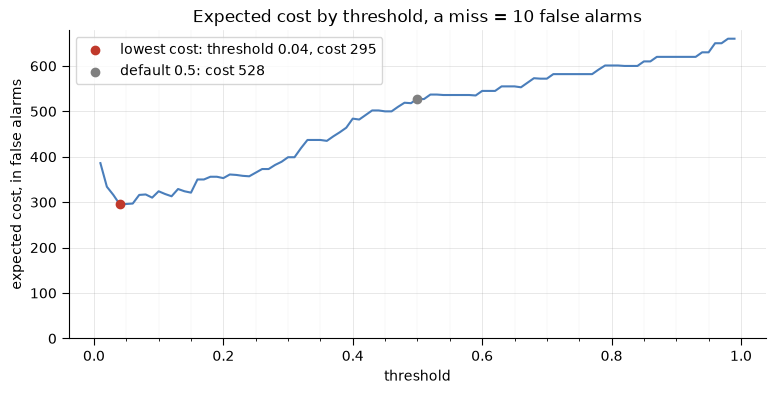

the default 0.5 costs 1.8 times as much as the best threshold


In [16]:
costs = []
for threshold in thresholds:
    tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, threshold)
    costs.append(fn * COST_RATIO + fp)

best_position = np.argmin(costs)
best_threshold = thresholds[best_position]
best_cost = costs[best_position]

tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, 0.5)
cost_at_half = fn * COST_RATIO + fp

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, costs, color=COST_COLOR)
ax.scatter(
    [best_threshold],
    [best_cost],
    color=BEST_COLOR,
    zorder=3,
    label=f"lowest cost: threshold {best_threshold:.2f}, cost {best_cost}",
)
ax.scatter(
    [0.5],
    [cost_at_half],
    color="gray",
    zorder=3,
    label=f"default 0.5: cost {cost_at_half}",
)
ax.set_ylim(bottom=0)
ax.set_title(f"Expected cost by threshold, a miss = {COST_RATIO} false alarms")
ax.set_xlabel("threshold")
ax.set_ylabel("expected cost, in false alarms")
ax.legend()
make_ax_better(ax, minor="x")
plt.show()

print(
    f"the default 0.5 costs {cost_at_half / best_cost:.1f} times "
    f"as much as the best threshold"
)

## 9. Read the optimum honestly

HW2 Part 5 asks for four things at the chosen threshold: the share of firms flagged, recall, precision, and the cost against 0.5. What does the bank actually do at the best threshold?

In [17]:
tn, fp, fn, tp = count_cells(y_true, bankrupt_proba, best_threshold)
print(
    f"threshold:     {best_threshold:.2f}\n"
    f"share flagged: {(tp + fp) / len(y_true):.0%}\n"
    f"recall:        {tp / (tp + fn):.0%}\n"
    f"precision:     {tp / (tp + fp):.0%}\n"
    f"cost:          {best_cost}, against {cost_at_half} at 0.5"
)

threshold:     0.04
share flagged: 9%
recall:        74%
precision:     28%
cost:          295, against 528 at 0.5


The bank flags 9% of all firms and catches 74% of the bankrupt ones. Precision is 28%, so **72% of the flags are false alarms, and this is the cheapest threshold.** When a miss costs as much as ten false alarms, a rational bank accepts crowds of false alarms. Optimal is not the same as pretty: say that sentence in your memo.

One honest caveat. We picked the threshold on the same test firms we report, so the cost of 295 is a little optimistic. HW2 accepts this. Demo 2 shows why a cleaner way exists.

## 10. The AI micro-moment, and other cost ratios

> Wrap this threshold scan into a function `compute_cost_curve(y_true, bankrupt_proba, ratio)` that returns the thresholds, the costs and the best threshold. Return only code.

One new bit in the returned code: `thresholds=np.arange(...)` inside `def` is a *default*. Python uses it when the caller doesn't pass its own thresholds. In `_, _, best = ...` the two `_` mark the values we don't need, as in section 7.

In [18]:
# code returned by the assistant; read every line, then run
def compute_cost_curve(
    y_true,
    bankrupt_proba,
    ratio,
    thresholds=np.arange(0.01, 1.0, 0.01),
):
    """Expected cost at each threshold: missed * ratio + false alarms."""
    costs = []
    for threshold in thresholds:
        called_bankrupt = bankrupt_proba >= threshold
        missed = ((~called_bankrupt) & (y_true == 1)).sum()
        false_alarms = (called_bankrupt & (y_true == 0)).sum()
        costs.append(missed * ratio + false_alarms)
    best_threshold = thresholds[np.argmin(costs)]
    return thresholds, costs, best_threshold


for ratio in [0.5, 5, 10, 25]:
    _, _, best_for_ratio = compute_cost_curve(y_true, bankrupt_proba, ratio)
    print(
        f"a missed bankruptcy = {ratio:>4} false alarms: "
        f"best threshold {best_for_ratio:.2f}"
    )

a missed bankruptcy =  0.5 false alarms: best threshold 0.82
a missed bankruptcy =    5 false alarms: best threshold 0.15
a missed bankruptcy =   10 false alarms: best threshold 0.04
a missed bankruptcy =   25 false alarms: best threshold 0.01


**Check before you trust.** At 10 the function returns 0.04, the same as our own scan in section 8. `(~called_bankrupt) & (y_true == 1)` is session 5's `~toy_is_flagged & toy_is_bankrupt`. A function that disagrees with your hand count is wrong until proven otherwise.

Read the four lines:

- **For one model, the dearer the miss, the lower the threshold.**
- **Below 1, a false alarm is the dearer mistake, and the best threshold climbs above 0.5.** That is HW2's `hotel_bookings`, where the ratio is 0.5.

Your HW2 dataset fixes your ratio, so a classmate with another dataset gets another threshold and other conclusions. That is HW2 Part 5: this curve, your ratio, and the honest sentence about false alarms.

A sanity check for your own data: a best threshold of 0.01 at a cost of 0 means your target is still text, not 1 and 0 (HW2, "Before you start").

## 11. Class weights move the dial

Session 5 promised it: class weights push every score up, which works much like lowering the threshold. Here is the same boosting with the weights on (`auto_class_weights="Balanced"`, as in session 5), and the best threshold of both models at 10 to 1.

In [19]:
weighted_model = CatBoostClassifier(
    iterations=300,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0,
)
weighted_model.fit(X_train, y_train)
weighted_bankrupt_proba = weighted_model.predict_proba(X_test)[:, 1]

_, _, best_without_weights = compute_cost_curve(y_true, bankrupt_proba, COST_RATIO)
_, _, best_with_weights = compute_cost_curve(
    y_true,
    weighted_bankrupt_proba,
    COST_RATIO,
)
print(
    f"best threshold without weights: {best_without_weights:.2f}\n"
    f"best threshold with weights:    {best_with_weights:.2f}"
)

best threshold without weights: 0.04
best threshold with weights:    0.23


Same firms, same cost ratio, and the best threshold moves. The business rule did not change; the scores did. So **compare thresholds within one model, never across models.**

Why did the scores change? The calibration check from section 2, now for the weighted model:

In [20]:
summarize_score_bands(y_true, weighted_bankrupt_proba)

,firms,average_score,bankrupt_share
score_band,,,
"(0.0, 0.02]",1657,0.003,0.003
"(0.02, 0.1]",179,0.048,0.073
"(0.1, 0.3]",97,0.181,0.062
"(0.3, 1.0]",113,0.636,0.372


The weighted model's firms scored about 0.18 went bankrupt only 6% of the time; those scored about 0.64, 37% of the time. **The weights pushed every score up, and the scores stopped being honest probabilities.** The order is still useful, so the cost curve still finds a good threshold, only at a higher number. With weights on, the best threshold can even land above 0.5 when misses are the dearer mistake.

HW2 Part 5 asks the next question: did the weights change the *cost* at the best threshold? Find that out on your own data.

## Try it yourself

1. Your HW2 ratio: run `compute_cost_curve` on your model and write the one-sentence verdict for the memo.
2. At 25 to 1, what share of firms does the bank flag? Is that workable for a credit team? What would you tell the head of risk?
3. Run `summarize_score_bands` on your own model's test scores. Are they honest probabilities? Would you put them into an expected-loss formula?
4. Stretch: the five-ratio logistic regression from session 5 (copy the cell from session 5, Demo 3, section 4: it standardizes with the training mean and std). Draw its ROC curve next to the boosting one. Does the simpler model choose a similar threshold?

In [21]:
# your turn

## Recap

- A model gives a **score**; a **threshold** turns it into a yes/no call. 0.5 is only the default.
- A score is an honest probability if it is **calibrated**: firms scored 0.2 go bankrupt about 20% of the time. Check it by score bands. The order is enough to choose a threshold; formulas need honest numbers.
- **The confusion matrix** is session 5's crosstab with names: TP caught, FN missed, FP false alarms, TN cleared. Textbooks put the positive class first; scikit-learn puts it last, and `.ravel()` reads tn, fp, fn, tp.
- Every mistake has a price, and the business sets it: screening watches recall, a spam filter watches precision. Either rate alone is easy to game.
- The threshold is a **menu**. The model doesn't pick the point; costs do.
- **ROC curve:** share of bankrupt firms caught against share of healthy firms flagged, one point per threshold. **AUC** is its area, and the chance that a random bankrupt firm outranks a random healthy one: 0.5 is a coin, 1.0 is perfect. Here 0.949, and still only 21% caught at 0.5.
- Expected cost = missed × ratio + false alarms. At 10 to 1 the best threshold is 0.04, and 0.5 costs 1.8 times as much. Optimal is not pretty: 72% false alarms can be the right answer.
- For one model, dearer misses mean lower thresholds; below 1 the threshold climbs above 0.5. Weights break calibration and move the threshold, so compare within one model. This is HW2 Part 5.